In [1]:
"""
=============================================================================
TASK 5 : Geographic Demand vs Bed Capacity Analysis
=============================================================================
Objective: Compare patient demand with available hospital capacity by location

Key Questions:
1. Which cities/states have high demand but low bed capacity? (Capacity Gap)
2. Where is there excess capacity that can be utilized?
3. What is the bed-to-patient ratio by location?
4. Which locations need immediate capacity expansion?

Columns Used:
    City, State           -> geographic grouping
    Patient_ID            -> count = patient demand
    Hospital_ID           -> unique hospital count
    Total_Beds            -> available capacity
    Latitude, Longitude   -> map positioning
    Hospital_Type         -> Private/Government breakdown
=============================================================================
"""

# To run the cells, try Shift+Enter instead of trying "Run Selected Cell and All Below" as it won't work or cause unnecessary delay.

'\n=============================================================================\nTASK 5 : Geographic Demand vs Bed Capacity Analysis\n=============================================================================\nObjective: Compare patient demand with available hospital capacity by location\n\nKey Questions:\n1. Which cities/states have high demand but low bed capacity? (Capacity Gap)\n2. Where is there excess capacity that can be utilized?\n3. What is the bed-to-patient ratio by location?\n4. Which locations need immediate capacity expansion?\n\nColumns Used:\n    City, State           -> geographic grouping\n    Patient_ID            -> count = patient demand\n    Hospital_ID           -> unique hospital count\n    Total_Beds            -> available capacity\n    Latitude, Longitude   -> map positioning\n    Hospital_Type         -> Private/Government breakdown\n=============================================================================\n'

# Download and Install required libraries

In [2]:
# download the required libraries, use !pip install **

!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

# use these for file reading

!pip install openpyxl
!pip install xlrd

# for geographic visualizations

!pip install folium
!pip install geopandas

# I already have jupyter and ipykernel available
# or use this one, remove the comment
#!pip install pandas numpy matplotlib seaborn openpyxl xlrd folium geopandas jupyter ipykernel


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Check if it is installed in your device

In [3]:
!pip list

Package                   Version
------------------------- ---------------
aiohappyeyeballs          2.6.1
aiohttp                   3.13.5
aiosignal                 1.4.0
annotated-doc             0.0.4
annotated-types           0.7.0
anyio                     4.13.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
branca                    0.8.2
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.7
click                     8.3.3
cohere                    5.21.1
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
dataclasses-json          0.6.7
debugpy                   1.8.20
decorator                 5.2.1
defusedxml    

# Begin analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings ('ignore')

print ("Begin\n\n" + "== " * 3 )
print ("TASK 5: GEOGRAPHIC DEMAND vs BED CAPACITY ANALYSIS")
print ("== " * 3 + "\n")

Begin

== == == 
TASK 5: GEOGRAPHIC DEMAND vs BED CAPACITY ANALYSIS
== == == 



### Check if dataset is available in your device

In [5]:
import pathlib
import os

_BASE = pathlib.Path().resolve ()

# this line checks for files in local storage
CANDIDATES = [
    "medical_operations_master_final.xlsx",
    "medical_operations_master_final.xls",
    "medical_operations_master.csv",
    "Hospital_Operations_Dataset.csv",
    "Hospital_Operations_Dataset 1.csv",
    "data/processed/medical_operations_master.csv",
]

DATA_PATH = None
for filename in CANDIDATES :
    p = _BASE / filename
    if p.exists () :
        DATA_PATH = str (p)
        print (f"Found: {filename}")
        break

if DATA_PATH is None :
    all_files = [f for f in os.listdir ('.') if f.endswith (('.csv', '.xls', '.xlsx'))]
    main_files = [f for f in all_files if not any ([
        f.startswith ('0'),
        'gap' in f.lower (),
        'chart' in f.lower (),
        'capacity_summary' in f.lower (),
        'critical_patient' in f.lower (),
        'department_utilization' in f.lower (),
        'staffing_workload' in f.lower (),
        'hospital_bed_capacity' in f.lower (),
    ])]
    
    if main_files :
        DATA_PATH = main_files [0]
        print (f"Found dataset: {DATA_PATH}")
    else :
        print ("\nNo main dataset found! Only analysis files detected.")
        print (f"   Available files: {all_files}")
        print ("\nPlease ensure your main dataset is in this folder.")
        print ("   It should be named like: medical_operations_master.xlsx")
        
        raise FileNotFoundError ("Main dataset not found!")


Found: medical_operations_master_final.xlsx


### If found, show statistics

In [6]:
print (f"\nLoading: {DATA_PATH}")

if DATA_PATH.endswith (('.xls', '.xlsx')) :
    try :
        df = pd.read_excel (DATA_PATH, engine = 'openpyxl')
        print ("Loaded with openpyxl engine")
    except Exception as e :
        print (f"openpyxl failed: {e}")
        try :
            df = pd.read_excel (DATA_PATH, engine = 'xlrd')
            print ("Loaded with xlrd engine")
        except Exception as e2 :
            print (f"xlrd failed: {e2}")
            df = pd.read_csv (DATA_PATH)
            print ("Loaded as CSV")
else :
    df = pd.read_csv (DATA_PATH)
    print ("Loaded as CSV")

print (f"\nDataset Info:")
print (f"   Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print (f"   Columns: {df.columns.tolist () [:10]}...")
print (f"   First 2 rows:\n{df.head (2)}")


Loading: C:\Users\HP\InfosysDataViz\medical_operations_master_final.xlsx
openpyxl failed: File is not a zip file
xlrd failed: Unsupported format, or corrupt file: Expected BOF record; found b'Patient_'
Loaded as CSV

Dataset Info:
   Shape: 100,000 rows x 28 columns
   Columns: ['Patient_ID', 'Age', 'Gender', 'Department_Patient', 'Diagnosis', 'Severity_Level', 'Admission_Date', 'Discharge_Date', 'Length_of_Stay_Days', 'Wait_Time_Minutes']...
   First 2 rows:
  Patient_ID  Age Gender Department_Patient       Diagnosis Severity_Level  \
0  PAT000001   23   Male         Gynecology          Cancer            Low   
1  PAT000002   48   Male          Neurology  Kidney Disease         Medium   

  Admission_Date Discharge_Date  Length_of_Stay_Days  Wait_Time_Minutes  ...  \
0     2026-05-02     2026-05-04                    2                 79  ...   
1     2026-03-24     2026-03-30                    6                167  ...   

    Hospital_Name         Branch        City       State Ho

## Now perform data cleaning

In [7]:
print ("\nDATA CLEANING...")

df ['Admission_Date'] = pd.to_datetime   (df['Admission_Date'],        errors = 'coerce')
df ['Discharge_Date'] = pd.to_datetime   (df['Discharge_Date'],   errors = 'coerce')

df = df.dropna (subset = ['Total_Beds', 'City', 'State', 'Latitude', 'Longitude']) # these are important

print (f"   Clean data shape: {df.shape}")
print (f"   Unique Cities: {df['City'].nunique()}")
print (f"   Unique States: {df['State'].nunique()}")
print (f"   Unique Hospitals: {df['Hospital_ID'].nunique()}")



DATA CLEANING...
   Clean data shape: (100000, 28)
   Unique Cities: 14
   Unique States: 12
   Unique Hospitals: 25


## Understand city-level demand versus capacity for valid analysis report and visualization

In [8]:
print ("\nCITY-LEVEL DEMAND vs CAPACITY...")

city_analysis = df.groupby (['City', 'State']).agg ({
    'Patient_ID'    : 'count',
    'Hospital_ID'   : 'nunique',
    'Total_Beds'    : 'sum',
    'Latitude'      : 'first',
    'Longitude'     : 'first',
    'Hospital_Type' : lambda x: x.value_counts().index[0] if len (x.value_counts()) > 0 else 'Unknown'
}).reset_index ()

city_analysis.columns = ['City', 'State', 'Patient_Demand', 'Hospital_Count', 
                         'Total_Beds', 'Latitude', 'Longitude', 'Primary_Hospital_Type']

# metrics calculation for bed utilization, beds per patient, and patients per bed
city_analysis ['Bed_Utilization'] = (city_analysis['Patient_Demand'] / city_analysis['Total_Beds'])    * 100
city_analysis ['Beds_per_Patient'] = city_analysis['Total_Beds']     / city_analysis['Patient_Demand']
city_analysis ['Patients_per_Bed'] = city_analysis['Patient_Demand'] / city_analysis['Total_Beds']

def classify_capacity (row) : # Capacity Status Classification (CSC)
    utilization = row ['Bed_Utilization']
    beds_per_patient = row['Beds_per_Patient']
    
    if utilization > 85 :
        return 'Over Capacity'  # Too high
    elif utilization > 70 :
        return 'Near Capacity'  # High but not critical
    elif utilization > 40 :
        return 'Optimal' # this is standard
    elif utilization > 15 :
        return 'Underutilized' # very low utilization
    else :
        return 'Severely Underutilized' # lower than all

city_analysis['Capacity_Status'] = city_analysis.apply (classify_capacity, axis = 1)

def demand_tier (demand) :
    if demand >= 10000 :
        return 'High Demand'
    elif demand >= 5000 :
        return 'Medium Demand'
    else :
        return 'Low Demand'

city_analysis['Demand_Tier'] = city_analysis['Patient_Demand'].apply(demand_tier)

city_analysis = city_analysis.sort_values('Patient_Demand', ascending = False).reset_index(drop = True)

print (f"Analyzed {len(city_analysis)} cities")



CITY-LEVEL DEMAND vs CAPACITY...
Analyzed 14 cities


## Understand state-level demand versus capacity to complete requirements

In [9]:
print ("\nSTATE-LEVEL DEMAND vs CAPACITY...")

state_analysis = df.groupby(['State']).agg({
    'Patient_ID': 'count',
    'Hospital_ID': 'nunique',
    'Total_Beds': 'sum',
    'City': 'nunique'
}).reset_index ()

state_analysis.columns = ['State', 'Patient_Demand', 'Hospital_Count', 'Total_Beds', 'City_Count']

state_analysis['Bed_Utilization'] = (state_analysis['Patient_Demand'] / state_analysis['Total_Beds'])    * 100
state_analysis['Beds_per_Patient'] = state_analysis['Total_Beds']     / state_analysis['Patient_Demand']
state_analysis['Patients_per_Bed'] = state_analysis['Patient_Demand'] / state_analysis['Total_Beds']

def classify_state_capacity (row) :
    utilization = row['Bed_Utilization']
    if utilization > 85 :
        return 'Over Capacity'
    elif utilization > 70 :
        return 'Near Capacity'
    elif utilization > 40 :
        return 'Optimal'
    elif utilization > 15 :
        return 'Underutilized'
    else:
        return 'Severely Underutilized'

state_analysis['Capacity_Status'] = state_analysis.apply(classify_state_capacity, axis = 1)
state_analysis = state_analysis.sort_values('Patient_Demand', ascending = False).reset_index(drop = True)

print (f"Analyzed {len(state_analysis)} states")



STATE-LEVEL DEMAND vs CAPACITY...
Analyzed 12 states


## Follow-up with hospital type

In [10]:
print ("\nHOSPITAL TYPE BREAKDOWN...")

hospital_type_analysis = df.groupby(['City', 'Hospital_Type']).agg({
    'Patient_ID': 'count',
    'Total_Beds': 'sum',
    'Hospital_ID': 'nunique'
}).reset_index()

hospital_type_analysis.columns = ['City', 'Hospital_Type', 'Patient_Demand', 'Total_Beds', 'Hospital_Count']

# Pivot for easier viewing
hospital_type_pivot = hospital_type_analysis.pivot_table(
    index = 'City',
    columns = 'Hospital_Type',
    values  =['Patient_Demand', 'Total_Beds'],
    fill_value = 0
)



HOSPITAL TYPE BREAKDOWN...


In [11]:
city_analysis.to_csv       ('05_city_demand_capacity_analysis.csv',  index = False)
state_analysis.to_csv      ('05_state_demand_capacity_analysis.csv', index = False)
hospital_type_pivot.to_csv ('05_hospital_type_breakdown.csv')

print ('Saved analysis as ')
print ("   05_city_demand_capacity_analysis.csv")
print ("   05_state_demand_capacity_analysis.csv")
print ("   05_hospital_type_breakdown.csv")

# Try to view your local storage, you'll find the csv files right there.

Saved analysis as 
   05_city_demand_capacity_analysis.csv
   05_state_demand_capacity_analysis.csv
   05_hospital_type_breakdown.csv


# Generating Visualizations

In [12]:
print ("\nGENERATING VISUALIZATIONS...")
print ("\nSetting up styles, please wait a moment...")

plt.style.use('dark_background')
colors = {'Over Capacity': '#e74c3c', 'Near Capacity': '#f39c12', 
          'Optimal': '#2ecc71', 'Underutilized': '#3498db', 
          'Severely Underutilized': '#95a5a6'}


GENERATING VISUALIZATIONS...

Setting up styles, please wait a moment...


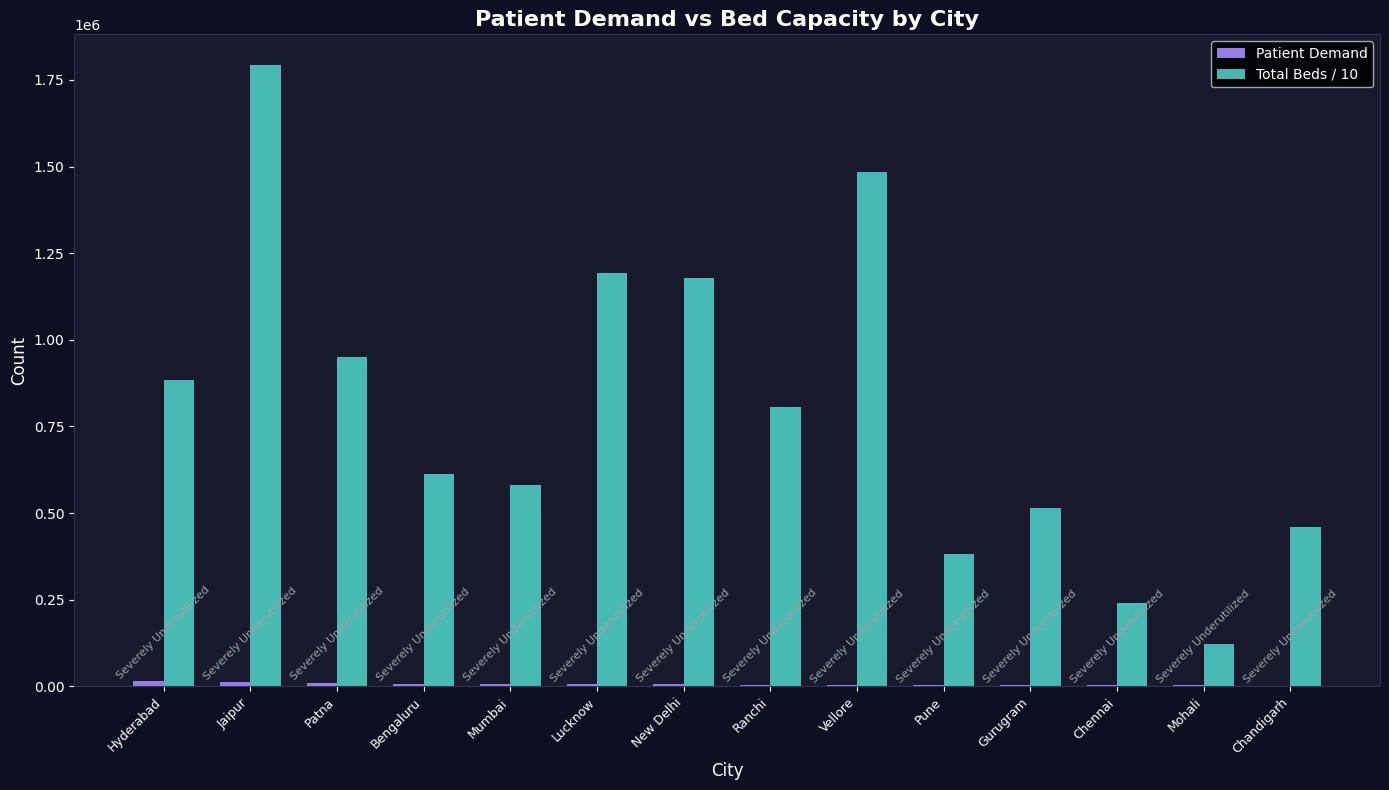

In [13]:
# --- FIGURE 1: City Demand vs Capacity (Bar Chart) ---
fig1, ax1 = plt.subplots(figsize = (14, 8))

x = np.arange  (len(city_analysis)) # arange
width = 0.35

bars1 = ax1.bar(x - width / 2, city_analysis['Patient_Demand'],  width, 
                label = 'Patient Demand',                        color = '#a78bfa', alpha = 0.9)
bars2 = ax1.bar(x + width / 2, city_analysis['Total_Beds'] / 10, width, 
                label = 'Total Beds / 10',                       color = '#4ecdc4', alpha = 0.9)

ax1.set_xlabel ('City',  fontsize = 12, color = 'white')
ax1.set_ylabel ('Count', fontsize = 12, color = 'white')

ax1.set_title ('Patient Demand vs Bed Capacity by City', fontsize = 16, color = 'white', fontweight = 'bold')
ax1.set_xticks (x)
ax1.set_xticklabels (city_analysis['City'], 
                     rotation = 45, ha = 'right', fontsize = 9, color = 'white')

ax1.legend (loc = 'upper right', fontsize = 10) # panel

# Add capacity status annotations
for i, row in city_analysis.iterrows () :
    status = row['Capacity_Status']
    color = colors.get(status, '#888888')
    
    ax1.text (i, row['Patient_Demand'] + max (city_analysis['Patient_Demand']) * 0.02,
             status,   ha = 'center',  va = 'bottom', 
             fontsize = 8, color = color, rotation = 45)

ax1.set_facecolor        ('#1a1a2e')
fig1.patch.set_facecolor ('#0f0f23')
ax1.tick_params          (colors = 'white')
ax1.spines[:].set_color  ('#333355')

plt.tight_layout ()

plt.savefig ('05_chart1_city_demand_vs_capacity.png', dpi = 150, bbox_inches = 'tight', facecolor = '#0f0f23') # dpi can be varied
plt.show ()

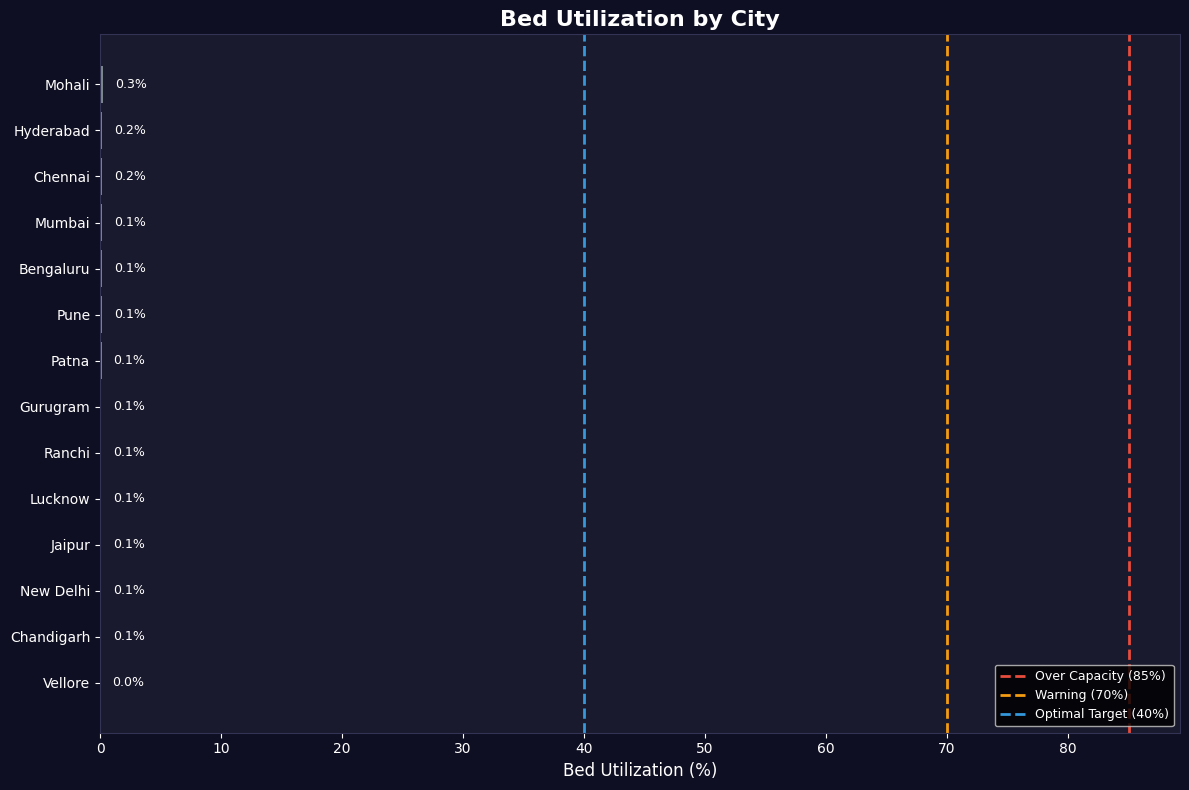

In [14]:
# --- FIGURE 2: Bed Utilization by City (Horizontal Bar) ---
print ('\n')

fig2, ax2 = plt.subplots (figsize = (12, 8))

sorted_df = city_analysis.sort_values ('Bed_Utilization', ascending = True)
colors_util = [colors.get(status, '#888888') for status in sorted_df['Capacity_Status']]

bars = ax2.barh(sorted_df['City'], sorted_df['Bed_Utilization'], color = colors_util, alpha = 0.8)

for bar, val in zip(bars, sorted_df['Bed_Utilization']) :
    ax2.text(bar.get_width() + 1,       bar.get_y() + bar.get_height () / 2,
             f'{val:.1f}%', va = 'center', fontsize = 9, color = 'white')

ax2.axvline (x = 85, color = '#e74c3c', linestyle = '--', linewidth = 2, label = 'Over Capacity (85%)')
ax2.axvline (x = 70, color = '#f39c12', linestyle = '--', linewidth = 2, label = 'Warning (70%)')
ax2.axvline (x = 40, color = '#3498db', linestyle = '--', linewidth = 2, label = 'Optimal Target (40%)')

ax2.set_xlabel('Bed Utilization (%)',    fontsize = 12, color = 'white')
ax2.set_title('Bed Utilization by City', fontsize = 16, color = 'white', fontweight = 'bold')

ax2.set_facecolor ('#1a1a2e')
fig2.patch.set_facecolor ('#0f0f23')

ax2.tick_params (colors = 'white')
ax2.spines[:].set_color ('#333355')
ax2.legend   (loc = 'lower right', fontsize = 9)

plt.tight_layout ()

plt.savefig ('05_chart2_bed_utilization_by_city.png', dpi = 150, bbox_inches = 'tight', facecolor = '#0f0f23')
plt.show ()


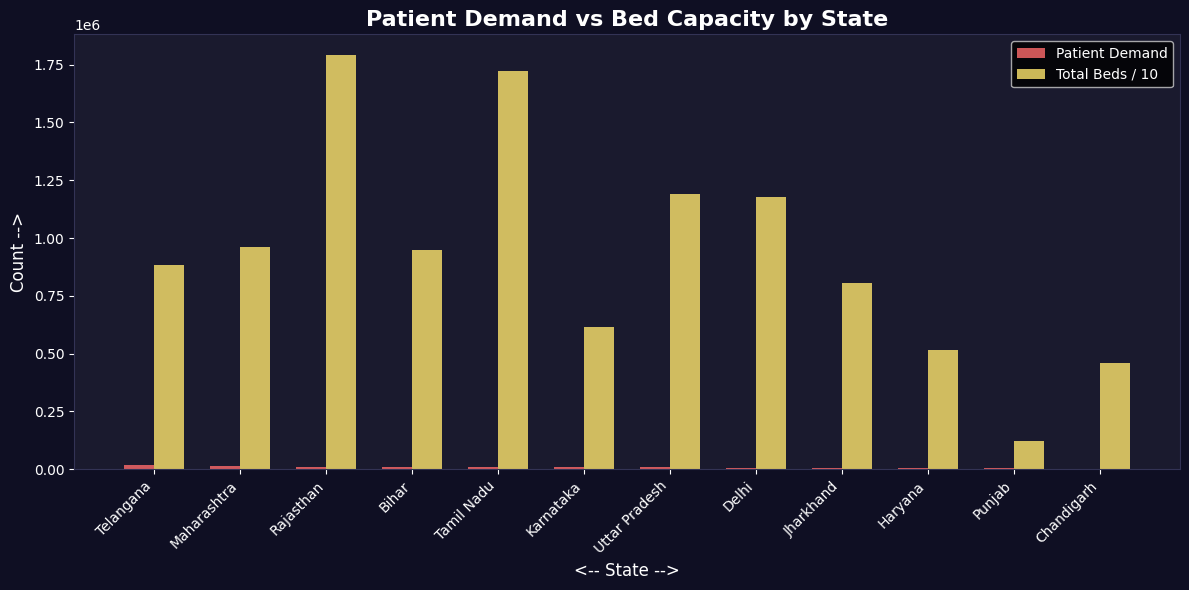

In [15]:
# --- FIGURE 3: State-Level Demand vs Capacity ---
fig3, ax3 = plt.subplots(figsize = (12, 6))

x = np.arange(len(state_analysis))
width = 0.35

bars1 = ax3.bar(x - width/2, state_analysis['Patient_Demand'], width, 
                label='Patient Demand', color='#ff6b6b', alpha=0.8)
bars2 = ax3.bar(x + width/2, state_analysis['Total_Beds'] / 10, width, 
                label='Total Beds / 10', color='#ffe66d', alpha=0.8)

ax3.set_xlabel ('<-- State -->', fontsize = 12, color = 'white')
ax3.set_ylabel ('Count -->', fontsize = 12, color = 'white')

ax3.set_title ('Patient Demand vs Bed Capacity by State', fontsize = 16, color = 'white', fontweight = 'bold')

ax3.set_xticks (x)
ax3.set_xticklabels (state_analysis['State'], rotation = 45, ha = 'right', fontsize = 10, color = 'white')
ax3.legend (loc = 'upper right', fontsize = 10)

ax3.set_facecolor ('#1a1a2e')
fig3.patch.set_facecolor ('#0f0f23')

ax3.tick_params (colors = 'white')
ax3.spines[:].set_color ('#333355')

plt.tight_layout ()
plt.savefig('05_chart3_state_demand_vs_capacity.png', dpi = 150, bbox_inches = 'tight', facecolor = '#0f0f23')
plt.show ()


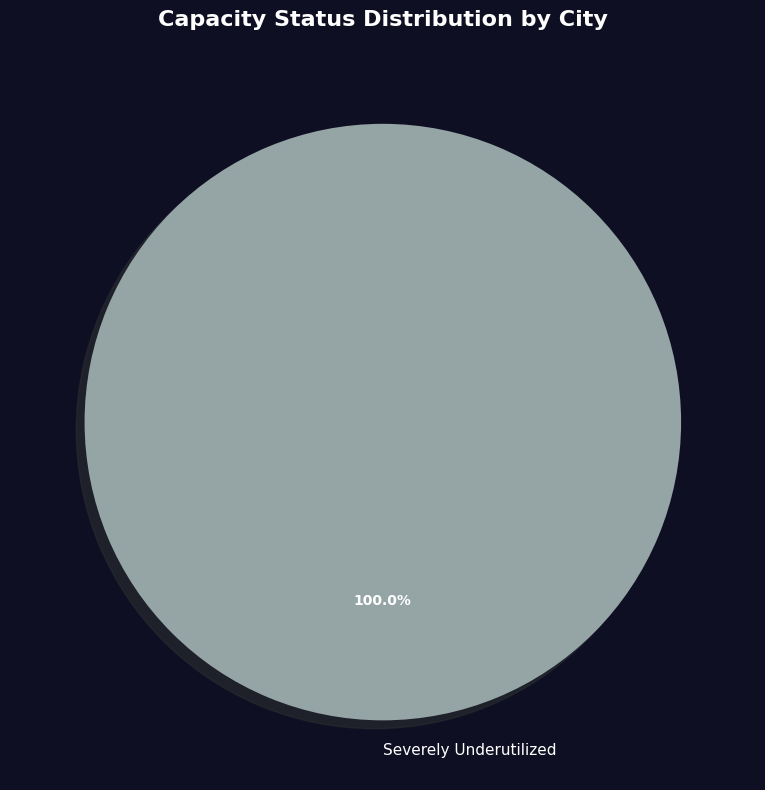

In [16]:
# --- FIGURE 4: Capacity Status Distribution (Pie) ---
fig4, ax4 = plt.subplots(figsize=(8, 8))

status_counts = city_analysis['Capacity_Status'].value_counts()
status_colors = [colors.get(s, '#888888') for s in status_counts.index]

wedges, texts, autotexts = ax4.pie(
    status_counts.values, 
    labels = status_counts.index,  colors = status_colors,
    autopct = '%1.1f%%',         startangle = 90,
    explode = [0.05] * len (status_counts),
    shadow = True)

for text in texts :
    text.set_color ('white')
    text.set_fontsize (11)
for autotext in autotexts :
    autotext.set_color ('white')
    autotext.set_fontweight ('bold')
    autotext.set_fontsize (10)

ax4.set_title ('Capacity Status Distribution by City', fontsize = 16, color = 'white', fontweight = 'bold')
fig4.patch.set_facecolor ('#0f0f23')
plt.tight_layout ()
plt.savefig ('05_chart4_capacity_status_distribution.png', dpi = 150, bbox_inches = 'tight', facecolor = '#0f0f23')
plt.show ()


# Interactive Map View

In [17]:
print("\nGENERATING INTERACTIVE MAP...")

# Create map centered on India
m = folium.Map(location = [22.5, 78.9], zoom_start = 5, tiles = 'CartoDB dark_matter')

# Color mapping for capacity status
status_colors = {
    'Over Capacity': '#e74c3c',
    'Near Capacity': '#f39c12',
    'Optimal': '#2ecc71',
    'Underutilized': '#3498db',
    'Severely Underutilized': '#95a5a6'
}

# Add city markers
for _, row in city_analysis.iterrows() :
    color = status_colors.get(row['Capacity_Status'], '#888888')
    radius = max (8,   min(25, int(row['Patient_Demand'] / 400)))
    
    popup_html = f"""
    <div style="font-family:Arial;min-width:220px;font-size:13px;">
        <h4 style="color:{color};margin:0 0 8px 0;">{row['City']}</h4>
        <p style="margin:3px 0;"><b>State:</b> {row['State']}</p>
        <p style="margin:3px 0;"><b>Patient Demand:</b> <b>{int(row['Patient_Demand']):,}</b></p>
        <p style="margin:3px 0;"><b>Total Beds:</b> <b>{int(row['Total_Beds']):,}</b></p>
        <p style="margin:3px 0;"><b>Bed Utilization:</b> <b>{row['Bed_Utilization']:.1f}%</b></p>
        <p style="margin:3px 0;"><b>Capacity Status:</b> 
            <span style="color:{color};font-weight:bold;">{row['Capacity_Status']}</span></p>
        <p style="margin:3px 0;"><b>Hospitals:</b> {int(row['Hospital_Count'])}</p>
        <p style="margin:3px 0;"><b>Hospital Type:</b> {row['Primary_Hospital_Type']}</p>
        <hr style="margin:6px 0;border-color:#333;">
        <p style="margin:3px 0;font-size:11px;color:#888;">
            Patients/Bed: {row['Patients_per_Bed']:.2f} | Beds/Patient: {row['Beds_per_Patient']:.2f}
        </p>
    </div>
    """
    
    folium.CircleMarker (
        location = [row['Latitude'], row['Longitude']],
        radius = radius,    color = '#ffffff',  weight = 2,
        fill = True,     fill_color = color,  fill_opacity = 0.85,
        popup = folium.Popup (popup_html, max_width = 280),
        tooltip = f"{row['City']}: {row['Capacity_Status']} | {int(row['Patient_Demand']):,} patients | {row['Bed_Utilization']:.1f}% utilization"
    ).add_to (m)



GENERATING INTERACTIVE MAP...


In [18]:
# Add HeatMap layer
heat_data = city_analysis[['Latitude', 'Longitude', 'Patient_Demand']].values.tolist()
HeatMap  (heat_data, radius = 25, blur = 20, min_opacity = 0.4).add_to(m)

# Add Legend
legend_html = """
<div style = "position: fixed; bottom: 30px; left: 30px; z-index: 9999;
    background: rgba (15,15,35,0.93); border: 1.5px solid #333355; border-radius:10px;
    padding: 14px 18px; font-family: Arial; color: white; min-width: 200px;">
    <p style = "margin: 0 0 8px 0; font-size: 14px; font-weight: bold; color: #a78bfa;">
        Capacity Status
    </p>
    <div style = "display: flex; align-items: center; margin-bottom: 4px;">
        <span style = "background:#e74c3c;width:14px;height:14px;border-radius:50%;display:inline-block;margin-right:8px;"></span>
        Over Capacity (>85%)
    </div>
    <div style = "display:flex;align-items:center;margin-bottom:4px;">
        <span style = "background:#f39c12;width:14px;height:14px;border-radius:50%;display:inline-block;margin-right:8px;"></span>
        Near Capacity (70-85%)
    </div>
    <div style = "display:flex;align-items:center;margin-bottom:4px;">
        <span style = "background: #2ecc71; width: 14px;height:14px; border-radius: 50%; display:inline-block; margin-right:8px;"></span>
        Optimal (40-70%)
    </div>
    <div style = "display:flex;align-items:center;margin-bottom:4px;">
        <span style = "background:#3498db;width:14px;height:14px;border-radius:50%;display:inline-block;margin-right:8px;"></span>
        Underutilized (15-40%)
    </div>
    <div style = "display:flex;align-items:center;">
        <span style = "background: #95a5a6; width: 14px; height: 14px; border-radius: 50%; display: inline-block; margin-right: 8px;"></span>
        Severely Underutilized (<15%)
    </div>
    <p style = "margin: 8px 0 0;    font-size: 10px; color: #888;">Circle size = patient demand</p>
</div>
"""
m.get_root().html.add_child (folium.Element  (legend_html))

# Add Title
title_html = """
<div style="position:fixed;top:12px;left:50%;transform:translateX(-50%);
    z-index:9999;background:rgba(15,15,35,0.93);border:1.5px solid #a78bfa;
    border-radius:10px;padding:10px 24px;font-family:Arial;color:white;text-align:center;">
    <span style="font-size:16px;font-weight:bold;color:#a78bfa;">
        Task 5 - Geographic Demand vs Bed Capacity
    </span><br>
    <span style="font-size:10px;color:#888;">Click circles for details | Red = Over Capacity</span>
</div>
"""
m.get_root ().html.add_child(folium.Element  (title_html))

# Save map
map_path = '05_geographic_demand_capacity_map.html'
m.save (map_path)
print (f"   Map saved: {map_path}")

# View your local storage for 05_geographic_demand_capacity_map.html file, open it to interact with the visual map.

   Map saved: 05_geographic_demand_capacity_map.html


# Analysis Summary

In [19]:
print ("\n" + "== " * 6)
print ("TASK 5 SUMMARY - GEOGRAPHIC DEMAND vs BED CAPACITY")
print ("== " * 6)

# Key findings
total_patients      = int (city_analysis['Patient_Demand'].sum ())
total_beds          = int (city_analysis['Total_Beds'].sum ())
overall_utilization = (total_patients / total_beds) * 100

over_capacity = city_analysis[city_analysis['Capacity_Status'] == 'Over Capacity']
near_capacity = city_analysis[city_analysis['Capacity_Status'] == 'Near Capacity']
underutilized = city_analysis[city_analysis['Capacity_Status'].isin (['Underutilized', 'Severely Underutilized'])]

print (f"\nOVERALL STATISTICS:")
print (f"   Total Patients: {total_patients:,}")
print (f"   Total Beds: {total_beds:,}")
print (f"   Overall Bed Utilization: {overall_utilization:.1f}%")
print (f"   Cities Analyzed: {len(city_analysis)}")

print (f"\nCAPACITY STATUS BREAKDOWN:")
print (f"   Over Capacity (>85%): {len(over_capacity)} cities")
print (f"   Near Capacity (70-85%): {len(near_capacity)} cities")
print (f"   Underutilized (<40%): {len(underutilized)} cities")

if len(over_capacity) > 0 :
    print(f"\nCRITICAL CITIES (Over Capacity):")
    for _, row in over_capacity.iterrows () :
        print(f"   - {row['City']}: {row['Bed_Utilization']:.1f}% utilization, {int(row['Patient_Demand']):,} patients, {int(row['Total_Beds']):,} beds")

if len (underutilized) > 0 :
    print(f"\nUNDERUTILIZED CITIES (Can accept patients):")
    for _, row in underutilized.head(5).iterrows():
        print(f"   - {row['City']}: {row['Bed_Utilization']:.1f}% utilization, {int(row['Patient_Demand']):,} patients, {int(row['Total_Beds']):,} beds")

print (f"\nTOP 5 HIGHEST DEMAND STATES:")

for _, row in state_analysis.head(5).iterrows () :
    print (f"   - {row['State']}: {int (row['Patient_Demand']):,} patients, {int(row['Total_Beds']):,} beds, {row['Bed_Utilization']:.1f}% utilization")

print ("\n" + "== " * 8)
print ("\n\nANALYSIS COMPLETE!\n\n")

print ("OUTPUT FILES:")
print ("   - 05_city_demand_capacity_analysis.csv")
print ("   - 05_state_demand_capacity_analysis.csv")
print ("   - 05_hospital_type_breakdown.csv")
print ("   - 05_chart1_city_demand_vs_capacity.png")
print ("   - 05_chart2_bed_utilization_by_city.png")
print ("   - 05_chart3_state_demand_vs_capacity.png")
print ("   - 05_chart4_capacity_status_distribution.png")

print (f"   - {map_path}") # View your local storage, you'll see all these files available

# File count: 3 CSVs, 4 PNGs, 1 HTML

print ("\n" + "== " * 8)


== == == == == == 
TASK 5 SUMMARY - GEOGRAPHIC DEMAND vs BED CAPACITY
== == == == == == 

OVERALL STATISTICS:
   Total Patients: 100,000
   Total Beds: 111,964,110
   Overall Bed Utilization: 0.1%
   Cities Analyzed: 14

CAPACITY STATUS BREAKDOWN:
   Over Capacity (>85%): 0 cities
   Near Capacity (70-85%): 0 cities
   Underutilized (<40%): 14 cities

UNDERUTILIZED CITIES (Can accept patients):
   - Hyderabad: 0.2% utilization, 16,501 patients, 8,831,220 beds
   - Jaipur: 0.1% utilization, 11,600 patients, 17,917,300 beds
   - Patna: 0.1% utilization, 11,150 patients, 9,490,550 beds
   - Bengaluru: 0.1% utilization, 8,255 patients, 6,139,600 beds
   - Mumbai: 0.1% utilization, 8,217 patients, 5,799,150 beds

TOP 5 HIGHEST DEMAND STATES:
   - Telangana: 16,501 patients, 8,831,220 beds, 0.2% utilization
   - Maharashtra: 13,314 patients, 9,621,900 beds, 0.1% utilization
   - Rajasthan: 11,600 patients, 17,917,300 beds, 0.1% utilization
   - Bihar: 11,150 patients, 9,490,550 beds, 0.1% u